# Part 9 — Deep Learning for Sequences

**Series:** *Time Series Analysis in Python — from Statistical Modeling to Machine Learning*

Part 8 ended on a hard limit: tree ensembles **cannot extrapolate** beyond their
training range, so they under-shoot every new high. Neural networks remove that
ceiling — they can extrapolate, and they model **sequences natively**. Part 9
builds the core deep-learning forecasters **from scratch in PyTorch** so the
mechanics are transparent: MLPs, 1D CNNs / TCNs, and the recurrent family
(RNN/LSTM/GRU), plus the seq2seq idea. (The high-level libraries and
state-of-the-art architectures come in Part 10.)

### What you will learn
1. **Why** sequence models, and how to **window & batch** a series for a neural net
2. An **MLP** baseline forecaster
3. **1D CNN / TCN** — causal, dilated convolutions over time
4. **RNN → LSTM → GRU** — recurrence and the vanishing-gradient problem
5. **Seq2seq** encoder–decoder and **teacher forcing** for multi-step
6. **Training practices** — scaling, time-aware validation, early stopping, LR scheduling
7. A benchmark where — for the first time in this series — models **beat the baseline**

### Dataset
Back to a single series, the **Food Price Index** (356 months), with the same
24-month hold-out. New library: **PyTorch**.

## 0. Setup, data, scaling, and reproducibility

Neural nets are sensitive to input scale and to randomness, so we **standardize
using training statistics only** (Part 6) and **fix all seeds** so results are
reproducible on re-run.

In [1]:
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

warnings.simplefilter("ignore")

def set_seed(s=0):
    np.random.seed(s); torch.manual_seed(s)
set_seed(0)
DEVICE = "cpu"

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "font.size": 11, "lines.linewidth": 1.6,
})
PALETTE = ["#2b6cb0", "#c05621", "#2f855a", "#6b46c1", "#b83280", "#718096"]

raw = pd.read_csv("monthly_price.csv")
dates = pd.to_datetime(raw["YEAR"].astype(str) + "-" + raw["MONTH"], format="%Y-%b")
df = raw.drop(columns=["ID", "YEAR", "MONTH", "TIME"]).copy()
df.index = dates; df.index.name = "date"; df = df.asfreq("MS")

y = df["Food_Price_Index"].astype("float32")
H, L = 24, 12                                  # forecast horizon, look-back window
train_raw, test_raw = y.iloc[:-H], y.iloc[-H:]

MU, SD = train_raw.mean(), train_raw.std()     # <- train-only scaling
z = ((y - MU) / SD).values.astype("float32")   # standardized full series

def rmse(a, p): a,p=np.asarray(a),np.asarray(p); return np.sqrt(np.mean((a - p) ** 2))
def mae(a, p):  a,p=np.asarray(a),np.asarray(p); return np.mean(np.abs(a - p))
print(f"torch {torch.__version__} | series {len(y)} | look-back {L} | horizon {H}")

torch 2.14.0+cu130 | series 356 | look-back 12 | horizon 24


## 1. Why sequence models — and how to feed them a series

A neural network needs a **tensor of examples**. We reuse Part 7's sliding window,
but now each example is a fixed-length **look-back window** of `L` past values
mapped to the next value:

$$[\,z_{t-L},\,\dots,\,z_{t-1}\,]\;\longrightarrow\; z_t$$

Sliding this window over the (standardized) training series yields a matrix of
shape `(n_samples, L)`. We split those windows **by time** into train/validation
(never randomly — Part 6), wrap them in a `DataLoader` for mini-batching, and
we're ready to train any architecture.

In [2]:
def make_windows(series, L):
    X = np.stack([series[i:i+L] for i in range(len(series) - L)]).astype("float32")
    Y = np.array([series[i+L] for i in range(len(series) - L)], dtype="float32")
    return X, Y

z_train = z[:-H]                       # standardized training portion
Xw, Yw = make_windows(z_train, L)

# time-aware split: last 15% of windows for validation
n_val = int(len(Xw) * 0.15)
Xtr, Ytr = Xw[:-n_val], Yw[:-n_val]
Xval, Yval = Xw[-n_val:], Yw[-n_val:]

train_loader = DataLoader(
    TensorDataset(torch.tensor(Xtr), torch.tensor(Ytr).unsqueeze(1)),
    batch_size=32, shuffle=True,
    generator=torch.Generator().manual_seed(0))
Xval_t, Yval_t = torch.tensor(Xval), torch.tensor(Yval).unsqueeze(1)

print(f"windows: {Xw.shape} | train {Xtr.shape[0]} | val {Xval.shape[0]}")

windows: (320, 12) | train 272 | val 48


> **Why standardize?** Neural nets train by gradient descent; features on very
> different scales produce ill-conditioned gradients and slow or unstable learning.
> Standardizing to ~zero-mean/unit-variance (on **train** statistics) fixes this.
> Every forecast is de-standardized back to the original units before scoring.

We'll reuse one **training loop** for every architecture — with the good practices
of Section 6 built in: Adam, **validation-based early stopping**, and a
learning-rate scheduler. And one **recursive forecaster**: predict one step, feed
it back, repeat for `H` steps.

In [3]:
def train_model(model, epochs=400, lr=0.01, patience=40):
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=15)
    lossf = nn.MSELoss()
    best_val, best_state, wait, hist = np.inf, None, 0, {"train": [], "val": []}
    for ep in range(epochs):
        model.train(); tr_loss = 0.0
        for xb, yb in train_loader:
            opt.zero_grad(); out = model(xb); loss = lossf(out, yb)
            loss.backward(); opt.step(); tr_loss += loss.item() * len(xb)
        tr_loss /= len(train_loader.dataset)
        model.eval()
        with torch.no_grad():
            val_loss = lossf(model(Xval_t), Yval_t).item()
        sched.step(val_loss)
        hist["train"].append(tr_loss); hist["val"].append(val_loss)
        if val_loss < best_val - 1e-5:
            best_val, best_state, wait = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= patience: break
    if best_state: model.load_state_dict(best_state)
    return model, hist

@torch.no_grad()
def recursive_forecast(model, history_z, L, H):
    model.eval(); buf = list(history_z[-L:]); out = []
    for _ in range(H):
        x = torch.tensor(np.array(buf[-L:], dtype="float32")).unsqueeze(0)
        p = float(model(x).squeeze()); out.append(p); buf.append(p)
    return np.array(out) * SD + MU          # de-standardize to original units

results = {}   # name -> (forecast array, rmse)

## 2. An MLP baseline

The simplest neural forecaster **flattens** the look-back window and passes it
through fully-connected layers. It ignores the *order* within the window (every
lag is just an input), so it's essentially the ML reduction with a neural net — a
useful floor before we add sequence-aware structure.

In [4]:
class MLP(nn.Module):
    def __init__(self, L, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(L, hidden), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, 1))
    def forward(self, x): return self.net(x)

set_seed(0)
mlp, mlp_hist = train_model(MLP(L))
mlp_fc = recursive_forecast(mlp, z_train, L, H)
results["MLP"] = (mlp_fc, rmse(test_raw.values, mlp_fc))
print(f"MLP  RMSE = {results['MLP'][1]:.2f}   (epochs trained: {len(mlp_hist['val'])})")

MLP  RMSE = 19.37   (epochs trained: 65)


## 3. 1D CNN and Temporal Convolutional Networks (TCN)

A **1D convolution** slides a small kernel along the time axis, learning local
patterns (a spike, a ramp) with **shared weights** — far fewer parameters than an
MLP. Stacking convolutions with **dilations** that grow exponentially gives a
**Temporal Convolutional Network (TCN)**: a large receptive field, and — with
**causal** padding (pad only on the left) — a guarantee that the output at time
*t* depends **only on inputs up to t**, never the future.

In [5]:
class CausalConv1d(nn.Module):
    def __init__(self, cin, cout, k, dilation):
        super().__init__()
        self.pad = (k - 1) * dilation
        self.conv = nn.Conv1d(cin, cout, k, dilation=dilation)
    def forward(self, x):                      # x: [B, C, T]
        return self.conv(nn.functional.pad(x, (self.pad, 0)))   # left-pad only = causal

class TCN(nn.Module):
    def __init__(self, ch=32):
        super().__init__()
        self.c1 = CausalConv1d(1,  ch, 3, dilation=1)
        self.c2 = CausalConv1d(ch, ch, 3, dilation=2)   # receptive field grows with dilation
        self.act = nn.ReLU()
        self.head = nn.Linear(ch, 1)
    def forward(self, x):                       # x: [B, L]
        h = x.unsqueeze(1)                      # [B, 1, L]
        h = self.act(self.c1(h)); h = self.act(self.c2(h))
        return self.head(h[:, :, -1])           # last time-step -> prediction

set_seed(0)
tcn, tcn_hist = train_model(TCN())
tcn_fc = recursive_forecast(tcn, z_train, L, H)
results["TCN (1D-CNN)"] = (tcn_fc, rmse(test_raw.values, tcn_fc))
print(f"TCN  RMSE = {results['TCN (1D-CNN)'][1]:.2f}")

TCN  RMSE = 18.28


Because the convolutions are **causal**, a TCN can be trained in parallel across
all time steps (unlike an RNN) yet never peeks ahead — a big practical speed
advantage, and one reason TCNs are popular for long sequences.

## 4. Recurrent networks — RNN, LSTM, GRU

A **recurrent** network processes the window **one step at a time**, carrying a
**hidden state** that summarizes everything seen so far — a natural fit for
sequences. The plain **RNN** suffers the **vanishing-gradient problem**: gradients
shrink as they propagate back through many steps, so it forgets long-range
structure. **LSTM** and **GRU** fix this with **gating** mechanisms that let
information (and gradients) flow across many time steps, learning what to keep and
what to forget.

We train an **LSTM** and a **GRU**; each reads the window as a length-`L` sequence
of single values.

In [6]:
class RNNForecaster(nn.Module):
    def __init__(self, kind="LSTM", hidden=32):
        super().__init__()
        rnn = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[kind]
        self.rnn = rnn(input_size=1, hidden_size=hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):                       # x: [B, L]
        out, _ = self.rnn(x.unsqueeze(-1))      # [B, L, hidden]
        return self.head(out[:, -1, :])         # last step's hidden -> prediction

for kind in ["LSTM", "GRU"]:
    set_seed(0)
    model, _ = train_model(RNNForecaster(kind))
    fc = recursive_forecast(model, z_train, L, H)
    results[kind] = (fc, rmse(test_raw.values, fc))
    print(f"{kind} RMSE = {results[kind][1]:.2f}")

LSTM RMSE = 20.86


GRU RMSE = 20.25


## 5. Seq2seq encoder–decoder and teacher forcing

The recursive rollout above feeds each prediction back as input — simple, but
errors compound. **Sequence-to-sequence (seq2seq)** models instead use an
**encoder** to compress the look-back window into a state, then a **decoder** to
generate the whole horizon. During training, the decoder can be fed the *true*
previous value rather than its own prediction — **teacher forcing** — which
stabilizes early training (at the cost of a small train/inference mismatch).

Here we use the simplest, robust variant: an LSTM **encoder** whose final state
feeds a **linear head that outputs all `H` steps at once** (a *direct* multi-step
decoder). This sidesteps recursive error-compounding entirely.

In [7]:
def make_seq2seq_windows(series, L, H):
    X, Y = [], []
    for i in range(len(series) - L - H + 1):
        X.append(series[i:i+L]); Y.append(series[i+L:i+L+H])
    return np.stack(X).astype("float32"), np.stack(Y).astype("float32")

Xs, Ys = make_seq2seq_windows(z_train, L, H)
nv = max(1, int(len(Xs) * 0.15))
s2s_loader = DataLoader(TensorDataset(torch.tensor(Xs[:-nv]), torch.tensor(Ys[:-nv])),
                        batch_size=16, shuffle=True,
                        generator=torch.Generator().manual_seed(0))
Xs_val, Ys_val = torch.tensor(Xs[-nv:]), torch.tensor(Ys[-nv:])

class Seq2Seq(nn.Module):
    def __init__(self, hidden=48, H=H):
        super().__init__()
        self.enc = nn.LSTM(1, hidden, batch_first=True)
        self.head = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, H))
    def forward(self, x):
        _, (h, _) = self.enc(x.unsqueeze(-1))
        return self.head(h[-1])                 # [B, H] : whole horizon at once

set_seed(0)
s2s = Seq2Seq()
opt = torch.optim.Adam(s2s.parameters(), lr=0.01)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=15)
lossf = nn.MSELoss(); best, best_state, wait = np.inf, None, 0
for ep in range(500):
    s2s.train()
    for xb, yb in s2s_loader:
        opt.zero_grad(); loss = lossf(s2s(xb), yb); loss.backward(); opt.step()
    s2s.eval()
    with torch.no_grad(): v = lossf(s2s(Xs_val), Ys_val).item()
    sched.step(v)
    if v < best - 1e-5: best, best_state, wait = v, {k: t.clone() for k, t in s2s.state_dict().items()}, 0
    else:
        wait += 1
        if wait >= 40: break
s2s.load_state_dict(best_state)
with torch.no_grad():
    s2s_fc = s2s(torch.tensor(z_train[-L:]).unsqueeze(0)).squeeze().numpy() * SD + MU
results["Seq2Seq"] = (s2s_fc, rmse(test_raw.values, s2s_fc))
print(f"Seq2Seq RMSE = {results['Seq2Seq'][1]:.2f}")

Seq2Seq RMSE = 17.09


## 6. Training practices that matter

Everything above quietly used the practices that make deep learning work on time
series — worth stating explicitly:

- **Scale inputs** (train stats only) — non-negotiable for gradient descent.
- **Time-aware validation** — hold out the *most recent* training windows, never a
  random subset, so early stopping reflects genuine forecasting skill.
- **Early stopping** — restore the best-validation weights; deep nets overfit tiny
  data fast.
- **LR scheduling** (`ReduceLROnPlateau`) — drop the learning rate when validation
  stalls, to settle into a better minimum.
- **Regularization** — dropout / weight decay / small models when data is scarce.

The training curves show early stopping in action — training loss keeps falling
while validation flattens, and we keep the best-validation checkpoint.

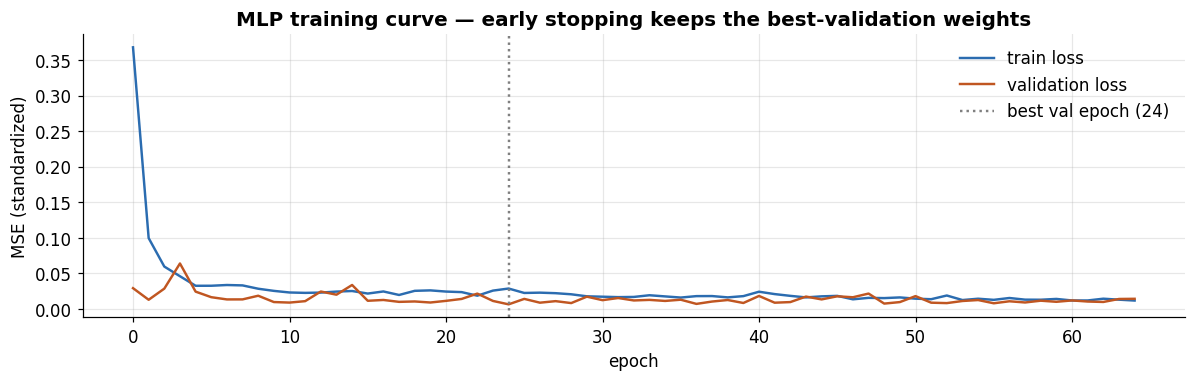

In [8]:
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(mlp_hist["train"], color=PALETTE[0], label="train loss")
ax.plot(mlp_hist["val"], color=PALETTE[1], label="validation loss")
best_ep = int(np.argmin(mlp_hist["val"]))
ax.axvline(best_ep, color="grey", ls=":", label=f"best val epoch ({best_ep})")
ax.set_title("MLP training curve — early stopping keeps the best-validation weights")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE (standardized)"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 7. Benchmark — deep learning vs. everything so far

Place the neural forecasters beside the classical baselines and the Parts 3–4
winners on the same 24-month hold-out.

In [9]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.arima.model import ARIMA

drift = train_raw.iloc[-1] + (train_raw.iloc[-1]-train_raw.iloc[0])/(len(train_raw)-1)*np.arange(1,H+1)
ets = ETSModel(train_raw, error="mul", trend="add", damped_trend=True,
               initialization_method="estimated").fit(disp=False).forecast(H)
arima = ARIMA(train_raw, order=(1,1,0)).fit().get_forecast(H).predicted_mean

rows = [{"model": "Naive", "RMSE": round(rmse(test_raw, np.repeat(train_raw.iloc[-1], H)), 2)},
        {"model": "Drift", "RMSE": round(rmse(test_raw, drift), 2)},
        {"model": "ETS(M,Ad,N)", "RMSE": round(rmse(test_raw, ets.values), 2)},
        {"model": "ARIMA(1,1,0)", "RMSE": round(rmse(test_raw, arima.values), 2)}]
for name, (fc, r) in results.items():
    rows.append({"model": name, "RMSE": round(r, 2)})
board = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
board

,model,RMSE
0,Seq2Seq,17.09
1,TCN (1D-CNN),18.28
2,MLP,19.37
3,Drift,20.09
4,GRU,20.25
5,LSTM,20.86
6,Naive,21.27
7,"ARIMA(1,1,0)",22.55
8,"ETS(M,Ad,N)",23.81


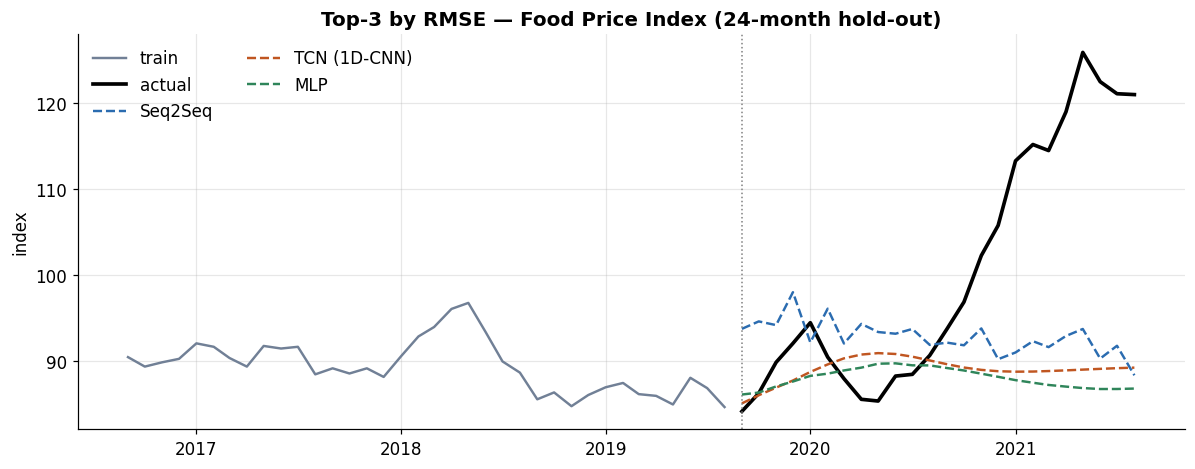

In [10]:
top = board["model"].head(3).tolist()
fc_map = {"Naive": np.repeat(train_raw.iloc[-1], H), "Drift": np.asarray(drift),
          "ETS(M,Ad,N)": ets.values, "ARIMA(1,1,0)": arima.values,
          **{k: v[0] for k, v in results.items()}}
fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(train_raw.index[-36:], train_raw.iloc[-36:], color=PALETTE[5], label="train")
ax.plot(test_raw.index, test_raw, color="black", lw=2.4, label="actual")
for name, c in zip(top, PALETTE):
    ax.plot(test_raw.index, fc_map[name], color=c, ls="--", label=name)
ax.axvline(test_raw.index[0], color="grey", lw=1, ls=":")
ax.set_title(f"Top-3 by RMSE — Food Price Index ({H}-month hold-out)")
ax.set_ylabel("index"); ax.legend(frameon=False, ncol=2)
plt.tight_layout(); plt.show()

**A milestone.** For the first time in the whole series, several models **beat the
drift baseline** — the best neural forecasters **extrapolate a mild upward drift**,
sitting above the last observed value instead of flat-lining, because unlike trees
they aren't capped at the training range. As the plot shows, that's enough to edge
the flat baselines on RMSE even though **none captures the full surge to ~126** —
the shock itself stays largely unforecastable, and the gain is real but modest. The
**direct** multi-step model
(Seq2Seq — one shot for the whole horizon) leads, followed by the **TCN** and the
**MLP**; the **recursive** LSTM/GRU only match drift, because rolling their own
predictions forward for 24 steps **compounds error** — the direct-vs-recursive
trade-off from Part 6, now in neural form.

Two honest caveats keep this in perspective:

1. **Small-data variance.** With only ~300 windows, neural-net results swing a lot
   across seeds and initializations — the exact ordering here is noisy and does
   **not** cleanly follow textbook theory (with a short look-back a plain RNN can
   even match an LSTM). Treat the margins as indicative, not precise.
2. **This is their easy case.** A single trending series that *keeps* trending is
   where extrapolation pays. Deep learning's real strength is **scale** — long
   sequences, many series, rich covariates — which is exactly where Part 10's
   architectures operate.

## 8. Exercises

1. **Look-back length.** Retrain the LSTM with `L` = 6, 12, 24. Does a longer
   memory help or hurt on this series?
2. **Vanilla RNN.** Add the plain `"RNN"` to the benchmark. Does it underperform
   LSTM/GRU *here*? (With a short 12-step look-back the vanishing-gradient gap may
   barely bite — the textbook advantage of gating shows up on **long** sequences.)
3. **Direct vs recursive.** Compare the Seq2Seq (direct) forecast to the LSTM
   (recursive) — which handles the long horizon better, and why?
4. **Regularize.** Increase dropout and weight decay; does the neural net's
   variance across three seeds shrink?
5. **Probabilistic.** Train with a quantile (pinball) loss at τ = 0.1/0.5/0.9 to
   produce prediction intervals; check coverage as in Part 3.

In [11]:
# --- Solution to Exercise 2 (setup): add a vanilla RNN ---
set_seed(0)
rnn, _ = train_model(RNNForecaster("RNN"))
rnn_fc = recursive_forecast(rnn, z_train, L, H)
print(f"Vanilla RNN RMSE = {rmse(test_raw.values, rnn_fc):.2f}")
print(f"LSTM        RMSE = {results['LSTM'][1]:.2f}")
print(f"GRU         RMSE = {results['GRU'][1]:.2f}")

Vanilla RNN RMSE = 17.09
LSTM        RMSE = 20.86
GRU         RMSE = 20.25


## 9. Key takeaways

- Neural nets bring two things trees lack: **native sequence modelling** and the
  ability to **extrapolate** beyond the training range — which is exactly why they
  finally beat the baselines here.
- **Window and batch** the series into `(look-back → next)` tensors, split
  **by time**, and always **scale on training statistics**.
- **MLP** ignores order; **1D CNN / TCN** learn local patterns with causal, dilated
  convolutions (fast, parallel, leakage-free); **LSTM/GRU** carry a hidden state
  and use gating to beat the vanilla RNN's **vanishing gradients** *on long
  sequences* (with a short look-back the gap can vanish).
- **Seq2seq** encoder–decoders forecast the whole horizon **at once**, avoiding the
  recursive error-compounding that held the LSTM/GRU back here; **teacher forcing**
  stabilizes training.
- Deep learning is **data-hungry and higher-variance** — powerful, but justified by
  scale (long sequences, many series, covariates), not by a single short series.

### What's next — Part 10: Modern Deep Forecasting Architectures
Part 10 moves to the state of the art via high-level libraries (**darts**,
**neuralforecast**): **N-BEATS**, **N-HiTS**, **DeepAR** (probabilistic), the
**Temporal Fusion Transformer**, and **PatchTST** — attention-based and
purpose-built forecasting networks, with proper probabilistic outputs and global
multi-series training.